# 鳶尾花(Iris) 分類

In [1]:
# 載入套件
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.utils import Bunch
from torch import nn, optim
from torch.nn import functional as F

## 載入 IRIS 資料集

In [2]:
dataset = cast(Bunch, datasets.load_iris())
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 資料分割成訓練及測試資料

In [3]:
target = np.asarray(dataset.target)
X_train, X_test, y_train, y_test = train_test_split(df.values, target, test_size=0.2)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

## 進行 one-hot encoding 轉換

In [4]:
# one-hot encoding
y_train_encoding = pd.get_dummies(y_train)
y_test_encoding = pd.get_dummies(y_test)

In [5]:
# 使用 PyTorch 函數
F.one_hot(torch.LongTensor(y_train))

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 

## 轉成 PyTorch Tensor

In [6]:
# 轉成 PyTorch Tensor
X_train = torch.FloatTensor(X_train)
y_train_encoding = torch.FloatTensor(y_train_encoding.values)
X_test = torch.FloatTensor(X_test)
y_test_encoding = torch.FloatTensor(y_test_encoding.values)
X_train.shape, y_train_encoding.shape

/var/folders/12/kxxl4khx6b9fjm12yv7z63y40000gn/T/ipykernel_19084/1281524071.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  y_train_encoding = torch.FloatTensor(y_train_encoding.values)


(torch.Size([120, 4]), torch.Size([120, 3]))

## 建立神經網路模型

In [7]:
model = nn.Sequential(
    nn.Linear(4, 3), 
    nn.Softmax(dim=1),
)

## 定義損失函數、優化器

In [8]:
loss_function = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 訓練模型

In [9]:
epochs = 1_000
accuracy: list[float] = []
losses: list[float] = []
for i in range(epochs):
    y_pred: torch.Tensor = model(X_train)
    loss = loss_function.forward(y_pred, y_train_encoding)

    # print(np.argmax(y_pred.detach().numpy(), axis=1))
    accuracy.append((np.argmax(y_pred.detach().numpy(), axis=1) == y_train).sum() / y_train.shape[0] * 100)
    losses.append(loss.item())

    # 梯度重置
    optimizer.zero_grad()

    # 反向傳導
    loss.backward()

    # 執行下一步
    optimizer.step()

    if i % 100 == 0:
        print(loss.item())

173.13330078125
75.31884002685547
36.760765075683594
21.328460693359375
15.161064147949219
11.812576293945312
9.754093170166016
8.379555702209473
7.405986785888672
6.685220718383789


## 繪製訓練過程的損失及準確率趨勢圖

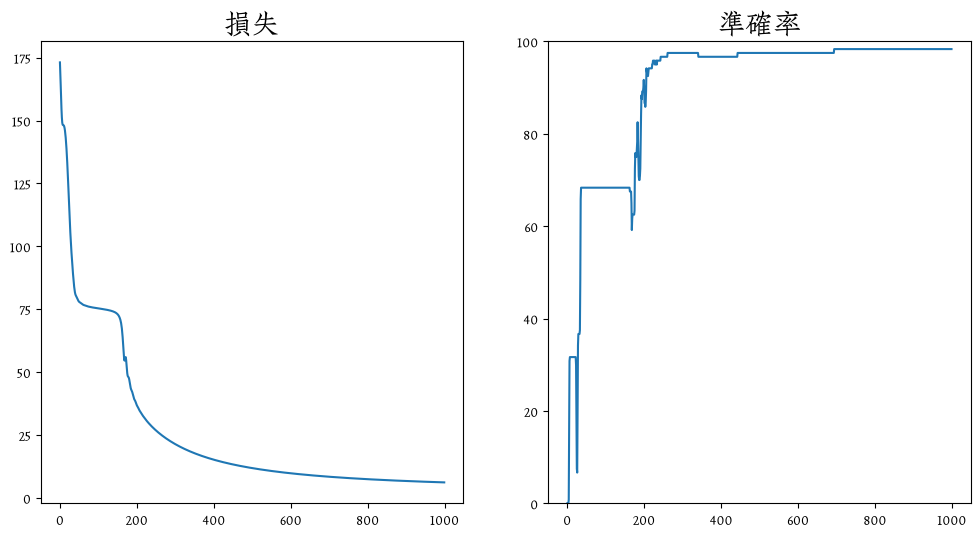

In [10]:
# fix 中文亂碼

plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('損失', fontsize=20)
plt.plot(range(0, epochs), losses)

plt.subplot(1, 2, 2)
plt.title('準確率', fontsize=20)
plt.plot(range(0, epochs), accuracy)
plt.ylim(0, 100)
plt.show()

## 模型評估

In [11]:
predict_test: torch.Tensor = model(X_test)
_, y_pred = torch.max(predict_test, 1)

print(f'測試資料準確度: {((y_pred.numpy() == y_test).sum()/y_test.shape[0]):.2f}')

測試資料準確度: 0.93
